In [1]:
import os
# from plasma_fusion_simulation_tools.microinstability_analysis.src.basic_analysis_tools.growth_rate.growth_rate_plotting import gamma_omega_plot

# from plasma_fusion_simulation_tools.microinstability_analysis.src.basic_analysis_tools.growth_rate.growth_rate_df_builder import growth_freq_dataframe

from GENE_sim_tools.sims_to_df.src.sims_to_dataframe import save_df_to_parquet, load_parquet_to_df, filepath_to_sim_df

from GENE_sim_tools.sims_to_df.src.field_data_analysis.append_field_analysis import complex_array_resolution_analysis


# 132588 q=4

## Filepaths

In [2]:
res_check_132588_q_4 = '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans'

In [3]:
# sim_df = filepath_to_sim_df(res_check_132588_q_4)

In [4]:
# analysis_sim_df = complex_array_resolution_analysis(sim_df)

In [5]:
# save_df_to_parquet(sim_df, res_check_132588_q_4, 'sim_df')

In [6]:
analysis_sim_df = load_parquet_to_df(res_check_132588_q_4, 'FIELD_ANALYSIS_sim_df.parquet')

Loading /pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/FIELD_ANALYSIS_sim_df.parquet


In [7]:
# analysis_sim_df = complex_array_resolution_analysis(load_sim_df)

In [8]:
analysis_sim_df.columns

Index(['n_procs_s', 'n_procs_v', 'n_procs_w', 'n_procs_x', 'n_procs_y',
       'n_procs_z', 'n_procs_sim', 'n_parallel_sims', 'n_spec', 'nx0',
       ...
       'Pi_EM3', 'diff_abs', 'corr_len', 'field_phi_ave_freq',
       'field_phi_lower_95_freq', 'field_phi_upper_95_freq',
       'field_phi_ave_angle', 'field_phi_lower_95_angle',
       'field_phi_upper_95_angle', 'fft_max_freq'],
      dtype='object', length=158)

In [9]:
analysis_sim_df['fft_max_freq']

0      0.499721
1      0.499721
2      0.499721
3      0.499721
4      0.499721
         ...   
367    0.499721
368    0.499721
369    0.499721
370    0.499721
371    0.499721
Name: fft_max_freq, Length: 372, dtype: float64

In [10]:
analysis_sim_df['corr_len'].unique()

array([       nan, 0.00110217, 0.00108449, 0.00195312, 0.30551188,
       0.3055104 , 0.3055116 , 0.17377098, 0.25623393, 0.25624619,
       0.25625541, 0.18544077, 0.20889896, 0.00325294, 0.00244314,
       0.00236264, 0.00390625, 0.35492346, 0.35491894, 0.35492685,
       0.29225832, 0.29227473, 0.2922881 , 0.20667596, 0.2300874 ,
       0.0078125 , 0.00438398, 0.00431369, 0.30148045, 0.30558294,
       0.30556883, 0.30557922, 0.00474127, 0.00462778, 0.42116972,
       0.42094087, 0.42091653, 0.26172636, 0.26184516, 0.26198374,
       0.26253296, 0.26267307, 0.26279881, 0.17906032, 0.24125492,
       0.33410951, 0.33407232, 0.33408972, 0.1938137 , 0.21022173,
       0.00438965, 0.00428424, 0.27145792, 0.27151802, 0.27155986,
       0.0062033 , 0.00435786, 0.0042349 , 0.00655743, 0.00487471,
       0.00470893, 0.41781862, 0.4176693 , 0.41753246, 0.34900976,
       0.35498273, 0.35494792, 0.3549971 , 0.29227483, 0.29231817,
       0.29233121, 0.20980213, 0.23901647, 0.002202  , 0.00216

In [11]:
print(analysis_sim_df[['gamma', 'kymin','corr_len']])

     gamma  kymin  corr_len
0      NaN    0.1       NaN
1      NaN    0.1       NaN
2      NaN    0.1       NaN
3      NaN    0.1       NaN
4      NaN    0.1       NaN
..     ...    ...       ...
367  0.177    2.0  0.003906
368  0.000    2.0       NaN
369  0.000    2.0       NaN
370  0.000    2.0       NaN
371  0.000    2.0       NaN

[372 rows x 3 columns]


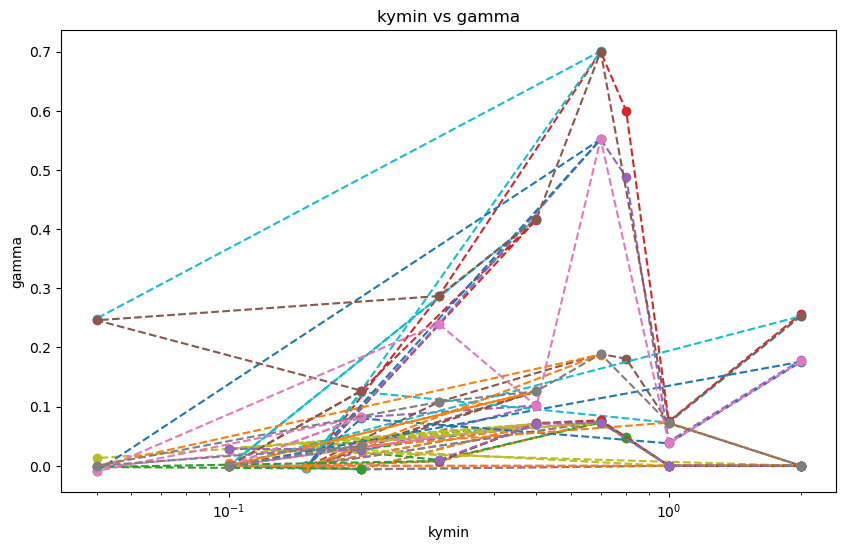

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming analysis_sim_df is your DataFrame

# Group the DataFrame by 'nz0', 'edge_opt', and 'hyp_z'
grouped = analysis_sim_df.groupby(['nz0', 'edge_opt', 'hyp_z'])

# Plotting
plt.figure(figsize=(10, 6))  # Set figure size for better visibility

for (nz0, edge_opt, hyp_z), group in grouped:
    if nz0==256:
        plt.plot(group['kymin'], group['gamma'], '--o', label=f'nz0={nz0}, edge_opt={edge_opt}, hyp_z={hyp_z}')

plt.xlabel('kymin')
plt.ylabel('gamma')
plt.title('kymin vs gamma')
plt.xscale('log')  # Set y-axis to logarithmic scale
# plt.legend()  # Show legend to identify the groups
plt.show()


In [13]:
filtered_columns = analysis_sim_df.filter(like='field_phi').columns
filtered_columns

Index(['field_phi_ave_freq', 'field_phi_lower_95_freq',
       'field_phi_upper_95_freq', 'field_phi_ave_angle',
       'field_phi_lower_95_angle', 'field_phi_upper_95_angle'],
      dtype='object')

40


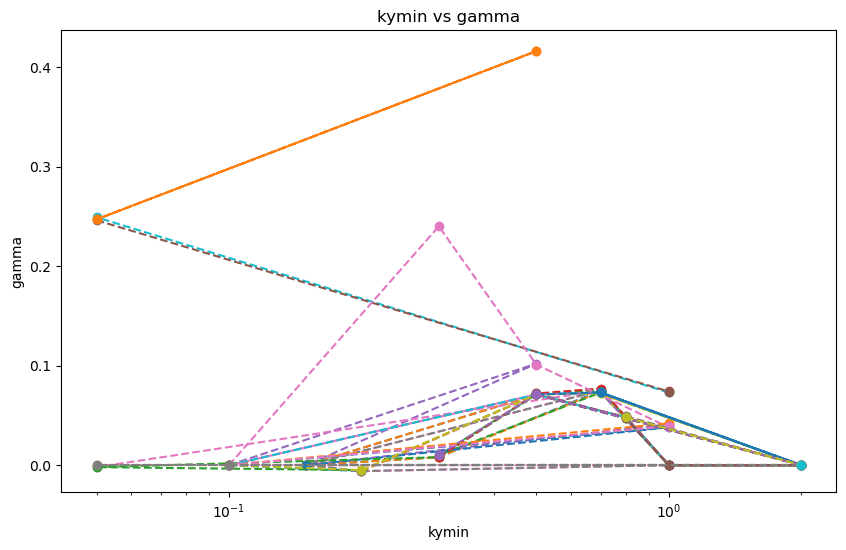

In [14]:
import pandas as pd
import matplotlib.pyplot as plt




# Initialize an empty list to store rows that meet the condition
filtered_rows = []
omitted_row = []

for _, row in analysis_sim_df.iterrows():

    if pd.notna(row['gamma']):
        max_freq = row['fft_max_freq']
        upper_95_freq = row['field_phi_upper_95_freq']
        # print(max_freq/2, upper_95_freq)
        if upper_95_freq < max_freq / 2:
            # Add the row to the list if it meets the condition
            filtered_rows.append(row)
        else:
            omitted_row.append(row)
            

# Convert the list of filtered rows into a DataFrame
filtered_analysis_sim_df = pd.DataFrame(filtered_rows)
omitted_sim_df = pd.DataFrame(omitted_row)


# Group the DataFrame by 'nz0', 'edge_opt', and 'hyp_z'
grouped = filtered_analysis_sim_df.groupby(['nz0', 'edge_opt', 'hyp_z'])


print(len(grouped))
# Plotting
plt.figure(figsize=(10, 6))  # Set figure size for better visibility

for (nz0, edge_opt, hyp_z), group in grouped:
    plt.plot(group['kymin'], group['gamma'], '--o', label=f'nz0={nz0}, edge_opt={edge_opt}, hyp_z={hyp_z}')

plt.xlabel('kymin')
plt.ylabel('gamma')
plt.title('kymin vs gamma')
plt.xscale('log')  # Set y-axis to logarithmic scale
# plt.legend()  # Show legend to identify the groups
plt.show()

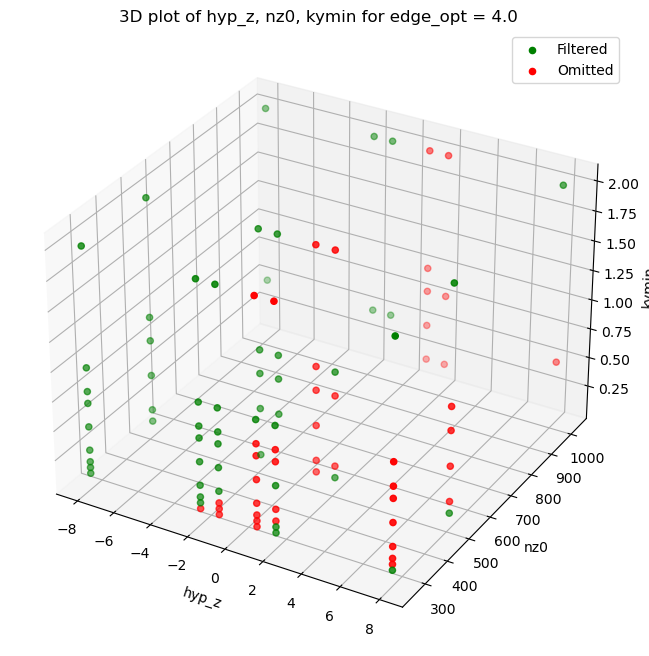

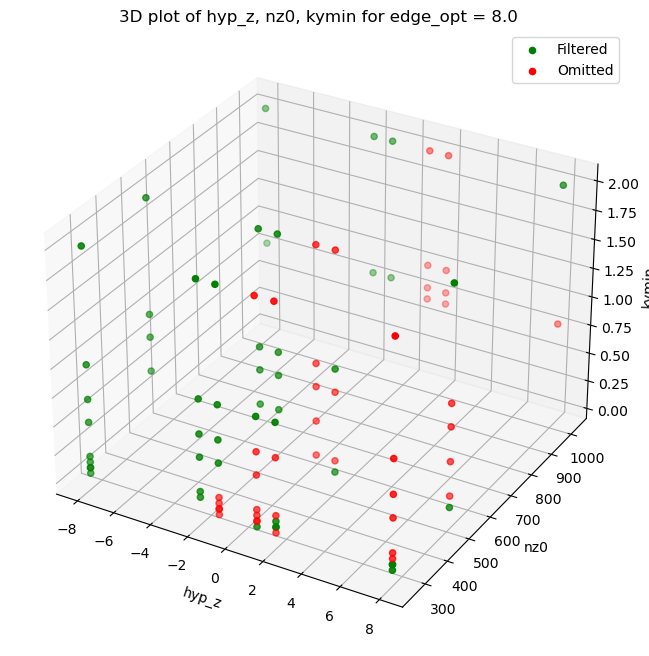

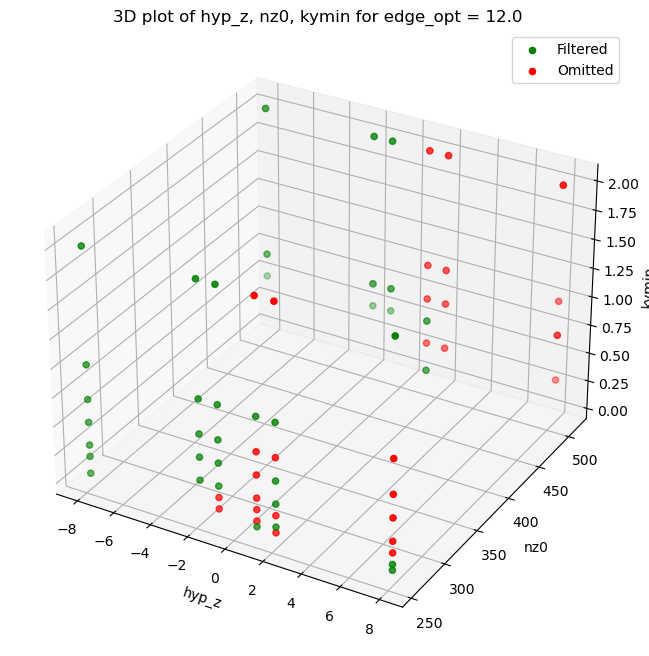

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assuming analysis_sim_df is already defined

# Initialize empty lists to store rows
filtered_rows = []
omitted_row = []

for _, row in analysis_sim_df.iterrows():
    if pd.notna(row['gamma']):
        max_freq = row['fft_max_freq']
        upper_95_freq = row['field_phi_upper_95_freq']
        if upper_95_freq < max_freq / 2:
            filtered_rows.append(row)
        else:
            omitted_row.append(row)

# Convert the lists to DataFrames
filtered_analysis_sim_df = pd.DataFrame(filtered_rows)
omitted_sim_df = pd.DataFrame(omitted_row)

# Get unique edge_opt values
unique_edge_opts = filtered_analysis_sim_df['edge_opt'].unique()

for edge_opt in unique_edge_opts:
    # Filter data for the current edge_opt
    edge_opt_filtered_subset = filtered_analysis_sim_df[filtered_analysis_sim_df['edge_opt'] == edge_opt]
    edge_opt_omitted_subset = omitted_sim_df[omitted_sim_df['edge_opt'] == edge_opt]

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter plot for 3D data: hyp_z, nz0, kymin
    ax.scatter(edge_opt_filtered_subset['hyp_z'], edge_opt_filtered_subset['nz0'], edge_opt_filtered_subset['kymin'], color='green', label='Filtered')
    ax.scatter(edge_opt_omitted_subset['hyp_z'], edge_opt_omitted_subset['nz0'], edge_opt_omitted_subset['kymin'], color='red', label='Omitted')

    ax.set_xlabel('hyp_z')
    ax.set_ylabel('nz0')
    ax.set_zlabel('kymin')
    plt.title(f'3D plot of hyp_z, nz0, kymin for edge_opt = {edge_opt}')
    plt.legend()
    plt.show()


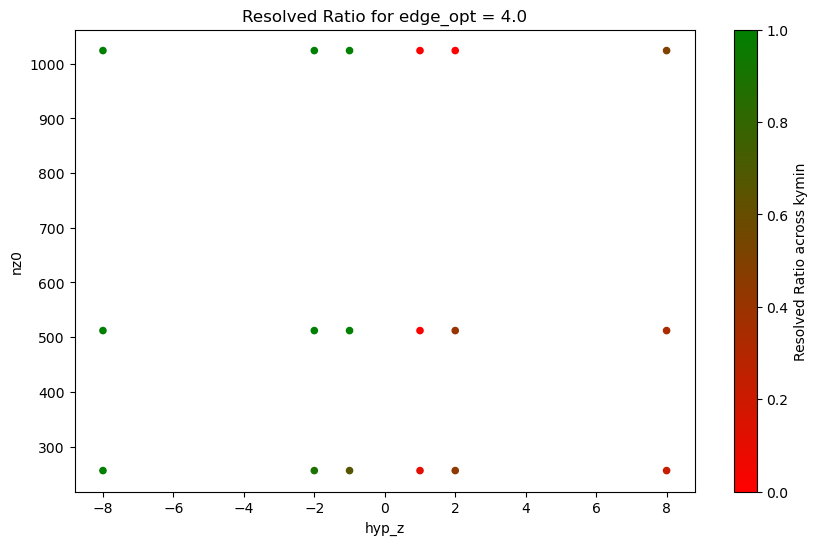

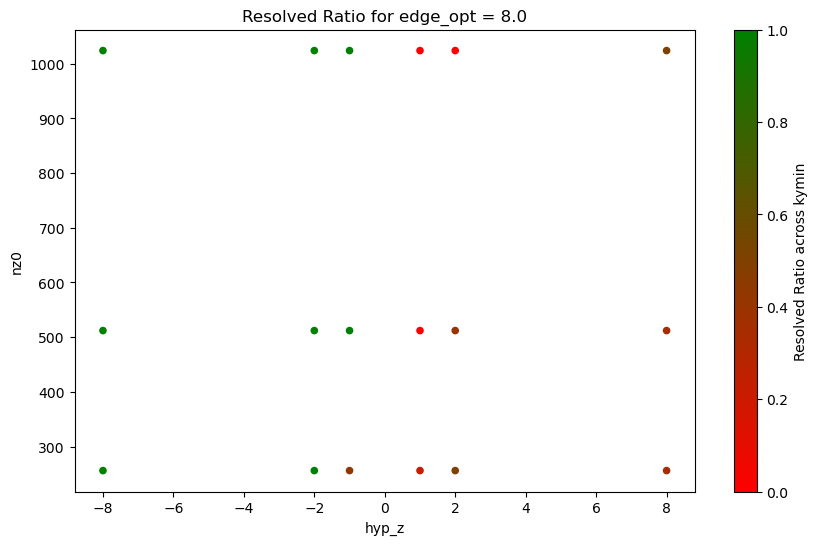

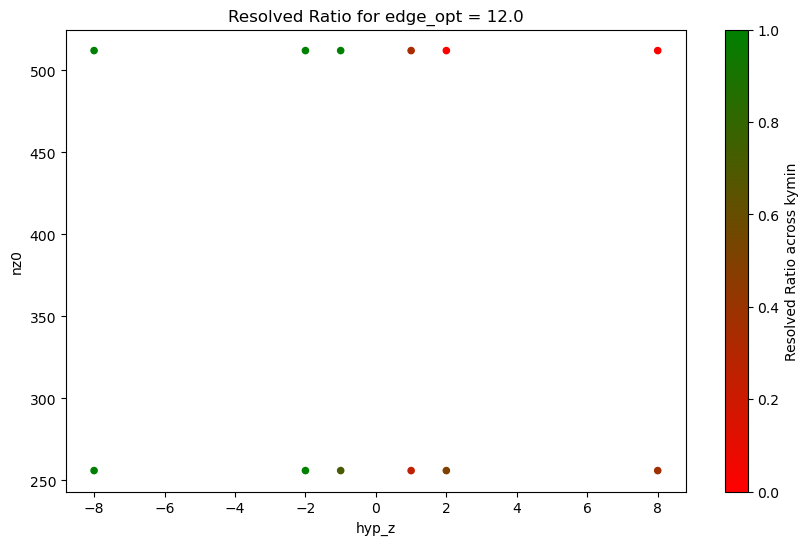

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Assuming analysis_sim_df is already defined

# Initialize empty lists to store rows
filtered_rows = []
omitted_row = []

for _, row in analysis_sim_df.iterrows():
    if pd.notna(row['gamma']):
        max_freq = row['fft_max_freq']
        upper_95_freq = row['field_phi_upper_95_freq']
        if upper_95_freq < max_freq / 2:
            filtered_rows.append(row)
        else:
            omitted_row.append(row)

# Convert the lists to DataFrames
filtered_analysis_sim_df = pd.DataFrame(filtered_rows)
omitted_sim_df = pd.DataFrame(omitted_row)

# Get unique edge_opt values
unique_edge_opts = filtered_analysis_sim_df['edge_opt'].unique()

# Define a custom colormap (red to green)
cmap = LinearSegmentedColormap.from_list('red_green', ['red', 'green'])

for edge_opt in unique_edge_opts:
    # Filter data for the current edge_opt
    edge_opt_subset = pd.concat([
        filtered_analysis_sim_df[filtered_analysis_sim_df['edge_opt'] == edge_opt],
        omitted_sim_df[omitted_sim_df['edge_opt'] == edge_opt]
    ])

    # Calculate counts
    total_counts = edge_opt_subset.groupby(['nz0', 'hyp_z']).size().reset_index(name='total')
    resolved_counts = filtered_analysis_sim_df[filtered_analysis_sim_df['edge_opt'] == edge_opt].groupby(['nz0', 'hyp_z']).size().reset_index(name='resolved')

    # Merge counts and calculate the ratio
    merged_counts = pd.merge(total_counts, resolved_counts, on=['nz0', 'hyp_z'], how='left').fillna(0)
    merged_counts['resolved_ratio'] = merged_counts['resolved'] / merged_counts['total']

    # Plotting
    plt.figure(figsize=(10, 6))
    points = plt.scatter(merged_counts['hyp_z'], merged_counts['nz0'], c=merged_counts['resolved_ratio'], cmap=cmap, s=20)
    plt.colorbar(points, label='Resolved Ratio across kymin')
    plt.xlabel('hyp_z')
    plt.ylabel('nz0')
    plt.title(f'Resolved Ratio for edge_opt = {edge_opt}')
    plt.show()


In [1]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # Assuming analysis_sim_df is already defined

# # Initialize empty lists to store rows
# filtered_rows = []
# omitted_row = []

# for _, row in analysis_sim_df.iterrows():
#     if pd.notna(row['gamma']):
#         max_freq = row['fft_max_freq']
#         upper_95_freq = row['field_phi_upper_95_freq']
#         if upper_95_freq < max_freq / 2:
#             filtered_rows.append(row)
#         else:
#             omitted_row.append(row)

# # Convert the lists to DataFrames
# filtered_analysis_sim_df = pd.DataFrame(filtered_rows)
# omitted_sim_df = pd.DataFrame(omitted_row)

# # Get unique edge_opt values
# unique_edge_opts = filtered_analysis_sim_df['edge_opt'].unique()

# for edge_opt in unique_edge_opts:
#     # Filter data for the current edge_opt
#     edge_opt_filtered_subset = filtered_analysis_sim_df[filtered_analysis_sim_df['edge_opt'] == edge_opt]
#     edge_opt_omitted_subset = omitted_sim_df[omitted_sim_df['edge_opt'] == edge_opt]
    
#     # Get unique kymin values within the current edge_opt subset
#     unique_kymins = edge_opt_filtered_subset['kymin'].unique()

#     for kymin in unique_kymins:
#         # Filter data for the current kymin within the current edge_opt
#         filtered_subset = edge_opt_filtered_subset[edge_opt_filtered_subset['kymin'] == kymin]
#         omitted_subset = edge_opt_omitted_subset[edge_opt_omitted_subset['kymin'] == kymin]

#         plt.figure(figsize=(10, 6))
#         plt.scatter(filtered_subset['hyp_z'], filtered_subset['nz0'], color='green', label='Resolved')
#         plt.scatter(omitted_subset['hyp_z'], omitted_subset['nz0'], color='red', label='Unresolved')

#         plt.xlabel('hyp_z')
#         plt.ylabel('nz0')
#         plt.title(f'hyp_z vs nz0 for edge_opt = {edge_opt} and kymin = {kymin}')
#         plt.legend()
#         plt.show()


In [15]:
omitted_sim_df[['kymin', 'nz0', 'edge_opt', 'hyp_z']]

kymin_counts = omitted_sim_df['kymin'].value_counts()
nz0_counts = omitted_sim_df['nz0'].value_counts()
edge_opt_counts = omitted_sim_df['edge_opt'].value_counts()
hyp_z_counts = omitted_sim_df['hyp_z'].value_counts()

kymin_counts, nz0_counts, edge_opt_counts, hyp_z_counts


(kymin
 2.00    21
 0.20    20
 0.70    17
 1.00    15
 0.80    14
 0.50    12
 0.30    10
 0.10    10
 0.15     6
 0.05     3
 Name: count, dtype: int64,
 nz0
 256     63
 512     47
 1024    18
 Name: count, dtype: int64,
 edge_opt
 4.0     46
 8.0     43
 12.0    39
 Name: count, dtype: int64,
 hyp_z
  1.0    49
  2.0    34
  8.0    34
 -1.0    10
 -2.0     1
 Name: count, dtype: int64)

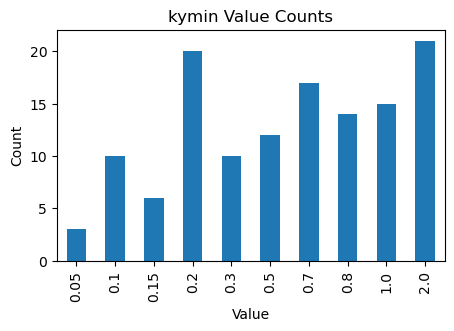

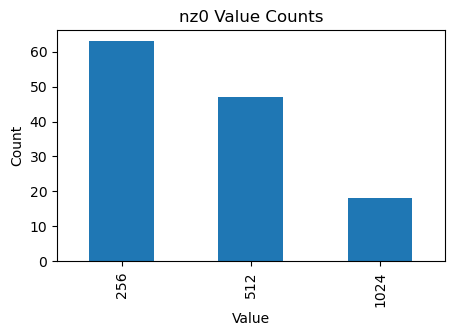

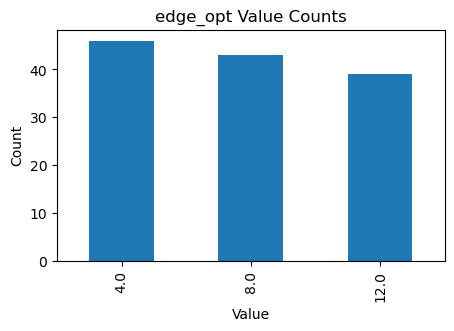

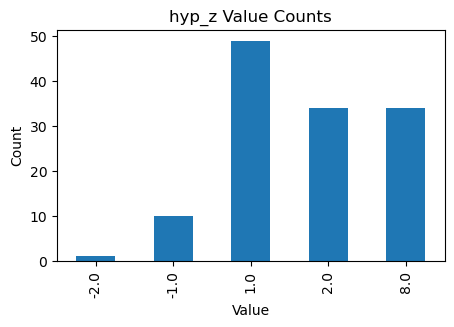

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming omitted_sim_df is your DataFrame and already loaded

# Calculate value counts for each column
kymin_counts = omitted_sim_df['kymin'].value_counts().sort_index()
nz0_counts = omitted_sim_df['nz0'].value_counts().sort_index()
edge_opt_counts = omitted_sim_df['edge_opt'].value_counts().sort_index()
hyp_z_counts = omitted_sim_df['hyp_z'].value_counts().sort_index()

# Function to plot the counts
def plot_counts(counts, title):
    plt.figure(figsize=(5, 3))
    counts.plot(kind='bar')
    plt.title(title)
    plt.xlabel('Value')
    plt.ylabel('Count')
    # plt.grid(True)
    plt.show()

# Plotting each column's value counts
plot_counts(kymin_counts, 'kymin Value Counts')
plot_counts(nz0_counts, 'nz0 Value Counts')
plot_counts(edge_opt_counts, 'edge_opt Value Counts')
plot_counts(hyp_z_counts, 'hyp_z Value Counts')


# nz0=256

In [17]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_256_edgeopt_04')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True, criteria_list=['edge_opt==4', 'nz0==256'])

NameError: name 'growth_freq_dataframe' is not defined

x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_08/scanfiles0006/omega_0018'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_08/scanfiles0002/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_08/scanfiles0000/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_08/scanfiles0006/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_08/scanfiles0005/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_08/scanfiles0001/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges

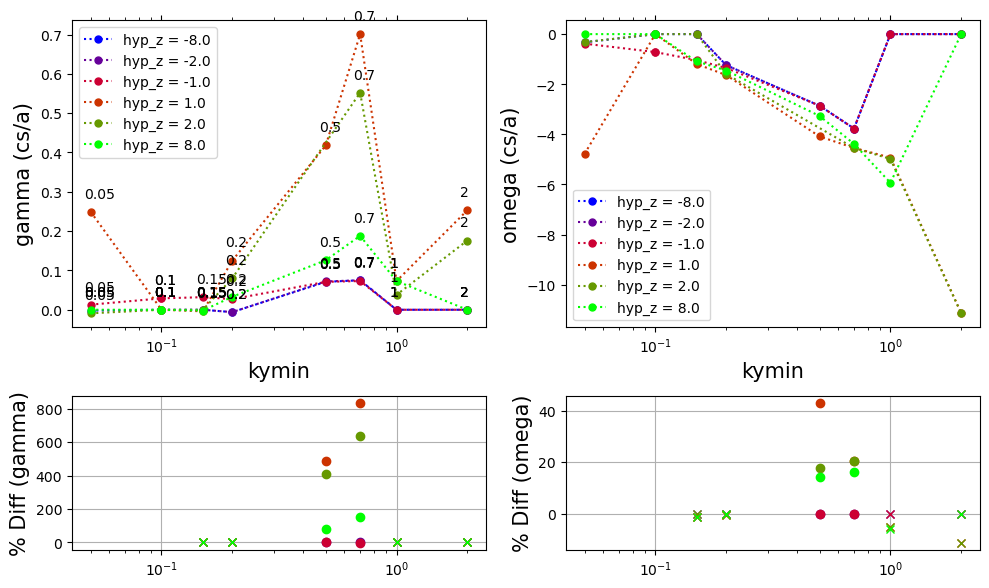

In [ ]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_256_edgeopt_08')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True, criteria_list=['edge_opt==8', 'nz0==256'])

x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_12/scanfiles0002/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_12/scanfiles0001/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_12/scanfiles0002/omega_0012'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_12/scanfiles0002/omega_0018'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_12/scanfiles0003/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_256_edgeopt_12/scanfiles0003/omega_0012'
 '/pscratch/sd/j/joeschm/NSXTU_discharges

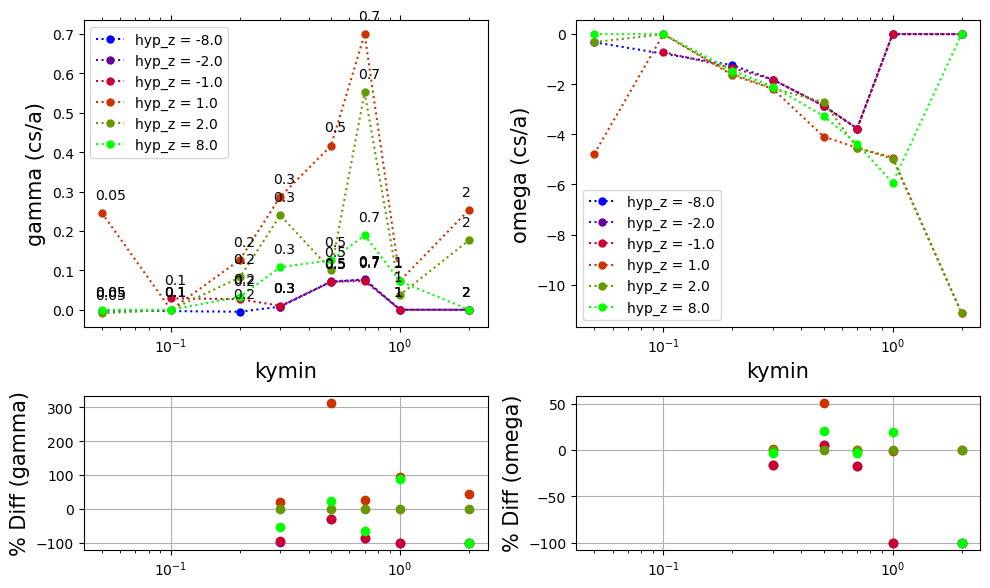

In [ ]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_256_edgeopt_12')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True, criteria_list=['edge_opt==12', 'nz0==256'])

# nz0 = 512

x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_04/scanfiles0000/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_04/scanfiles0000/omega_0012'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_04/scanfiles0000/omega_0018'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_04/scanfiles0001/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_04/scanfiles0001/omega_0012'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_04/scanfiles0001/omega_0018']
x-values for filepath: ['/pscratch/sd/j/

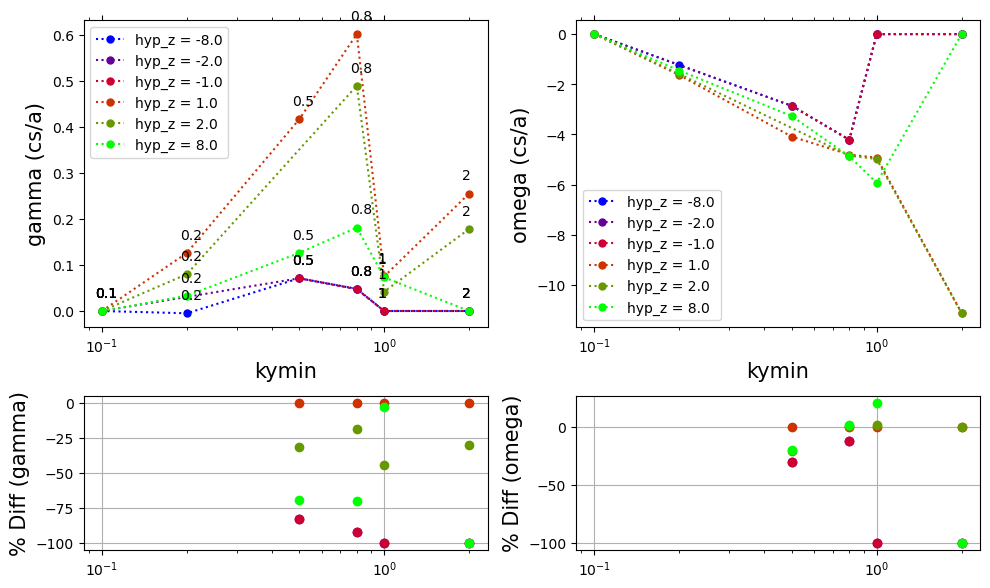

In [ ]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_512_edgeopt_04')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True, criteria_list=['edge_opt==4', 'nz0==512'])

x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_08/scanfiles0000/omega_0018'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_08/scanfiles0001/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_08/scanfiles0001/omega_0012'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_08/scanfiles0001/omega_0018']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_08/scanfiles0000/omega_0016'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_08/scanfiles0001/omega_0004'
 '/pscratch/sd/j/

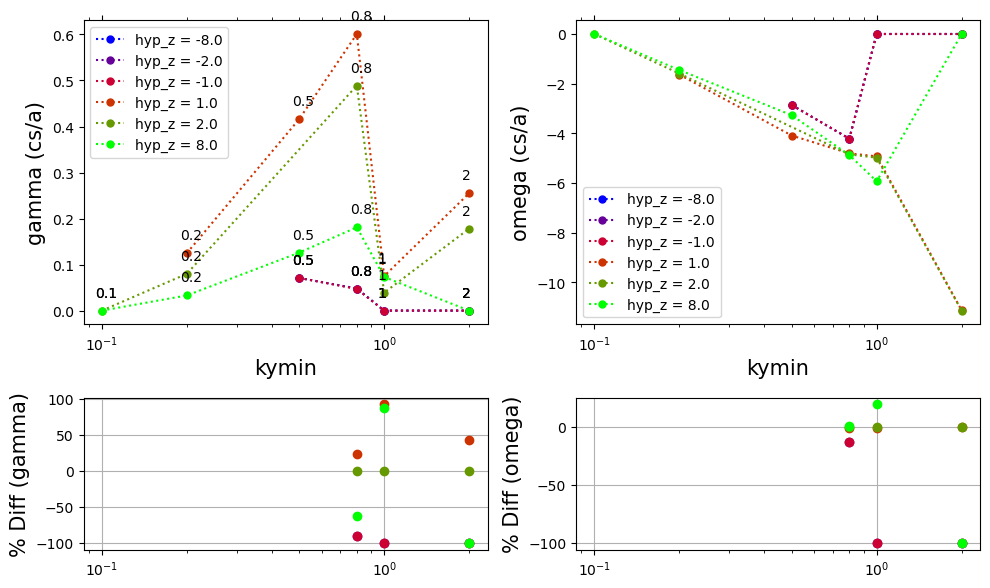

In [ ]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_512_edgeopt_08')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True, criteria_list=['edge_opt==8', 'nz0==512'])

x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_12/scanfiles0001/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_12/scanfiles0001/omega_0018']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_12/scanfiles0001/omega_0004'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_12/scanfiles0001/omega_0016']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_12/scanfiles0001/omega_0003'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_512_edgeopt_12/scanfiles0001/omega

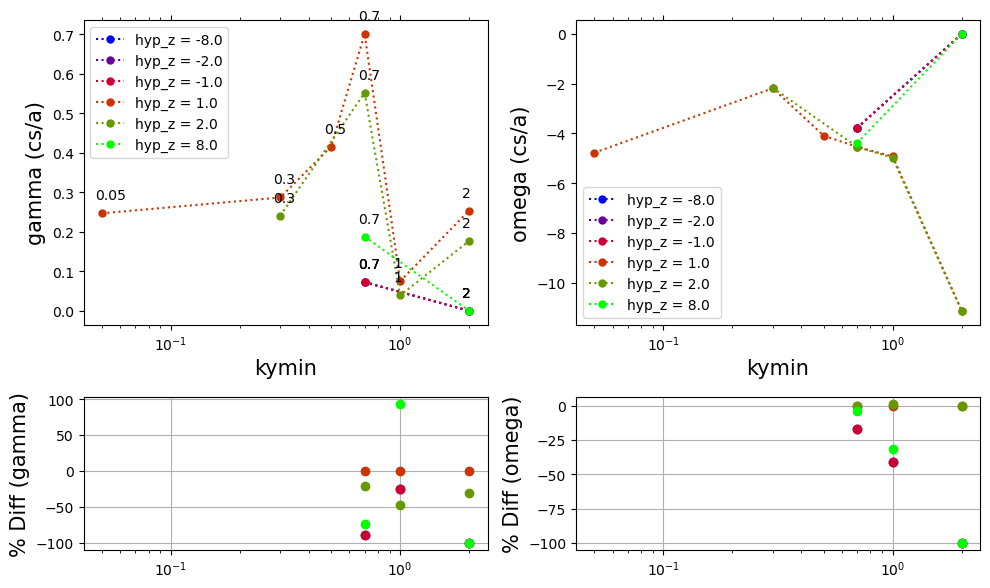

In [ ]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_512_edgeopt_12')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True, criteria_list=['edge_opt==12', 'nz0==512'])

# nz0 = 1024

x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_04/scanfiles0001/omega_0018']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_04/scanfiles0001/omega_0016']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_04/scanfiles0001/omega_0015']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_04/scanfiles0000/omega_0013'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_04/scanfiles0001/omega_0001'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_

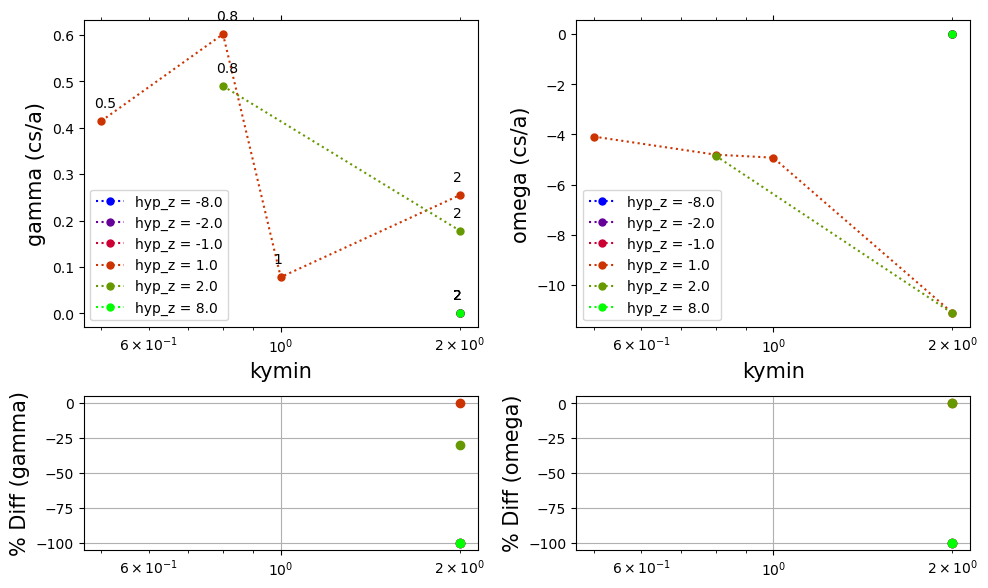

In [ ]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_1024_edgeopt_04')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True)

x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_08/scanfiles0000/omega_0006'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_08/scanfiles0000/omega_0018']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_08/scanfiles0000/omega_0004'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_08/scanfiles0000/omega_0016']
x-values for filepath: ['/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_08/scanfiles0000/omega_0003'
 '/pscratch/sd/j/joeschm/NSXTU_discharges/132588/r_0.736_q=4_MTM_mode/convergence_check/nz0_hpyz_edgeopt_scans/nz0_1024_edgeopt_08/scanfiles0000

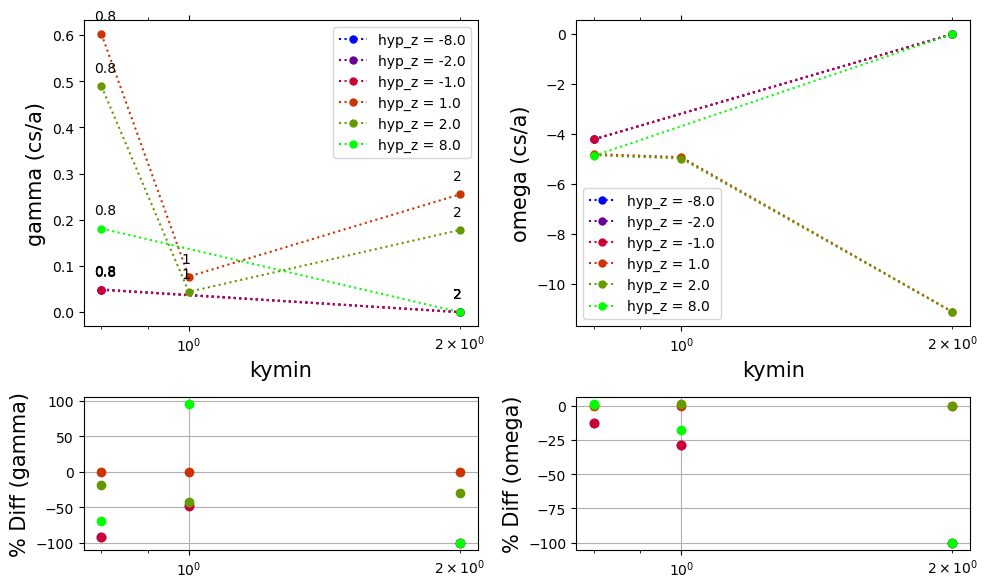

In [ ]:
scan_path = os.path.join(res_check_132588_q_4, 'nz0_1024_edgeopt_08')
growth_df = growth_freq_dataframe(scan_path)

gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True)

In [ ]:
# scan_path = os.path.join(res_check_132588_q_4, 'nz0_1024_edgeopt_12')
# growth_df = growth_freq_dataframe(scan_path)

# gamma_omega_plot(scan_path, label_key='hyp_z', verbose=True)

FileNotFoundError: No files of type 'parameters' were found at a depth of 3 for the given filepath.